In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\hbmnl_mixture_experiments\1_chain\2_comp
scenario=2comp_equal  K_MODEL=5  K_TRUE=2
samplers found: ['bayesm', 'HMC', 'NUTS', 'replication']


  bayesm   mu (1, 10000, 5, 4)
  HMC      mu (1, 10000, 5, 4)
  NUTS     mu (1, 10000, 5, 4)
  replication mu (1, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth & Grids (Full, unbounded  +  Chebyshev-filtered) ──────────
# Two grids are built per parameter and carried through every cell below. Neither
# uses the True DGP to set bounds beyond including it in the envelope/moments -
# it stays an overlay only.
#   "Full"                   - mc.build_grids_full: raw min/max envelope over EVERY
#                               component (all K, incl. surplus/empty ones) of every
#                               sampler and the True DGP. Nothing is excluded, so every
#                               metric integrates over the ENTIRE marginal - but a
#                               diffuse empty component (K_MODEL > K_TRUE) or a sampler
#                               exploring far off the high-density area can stretch this
#                               range enormously and squash the real mass into a few
#                               pixels.
#   "Chebyshev (k=5, >=96%)" - mc.build_grids_chebyshev: clipped to each model's own
#                               AGGREGATE mixture [mean - 5*std, mean + 5*std] (Eq.
#                               5.5.2). Chebyshev's inequality, P(|X-mean|>=k*std) <=
#                               1/k**2, holds for ANY distribution with finite variance
#                               (no normality/unimodality assumption - the invariant
#                               marginal is itself a mixture) - so >=1 - 1/5**2 = 96% of
#                               each model's own marginal mass is guaranteed to lie
#                               inside its window, trimming the outlier-driven tails of
#                               "Full" while keeping a distribution-free coverage bound.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

GRIDS = {
    "Full":                  mc.build_grids_full(models, true_model, n_grid=1000, n_sigma=6),
    "Chebyshev (k=5, >=96%)": mc.build_grids_chebyshev(models, true_model, n_grid=1000, k=5.0),
}
for label, grids in GRIDS.items():
    print(f"Grid extents [{label}]:")
    for j, pj in enumerate(param_names):
        print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

Grid extents [Full]:
  Alt1       [-1134.24, +1378.71]
  Alt2       [-761.20, +763.81]
  Alt3       [-366.91, +402.87]
  Price      [-516.02, +439.61]
Grid extents [Chebyshev (k=5, >=96%)]:
  Alt1       [-12.77, +17.11]
  Alt2       [-20.01, +21.93]
  Alt3       [-7.83, +12.36]
  Price      [-21.64, +11.66]


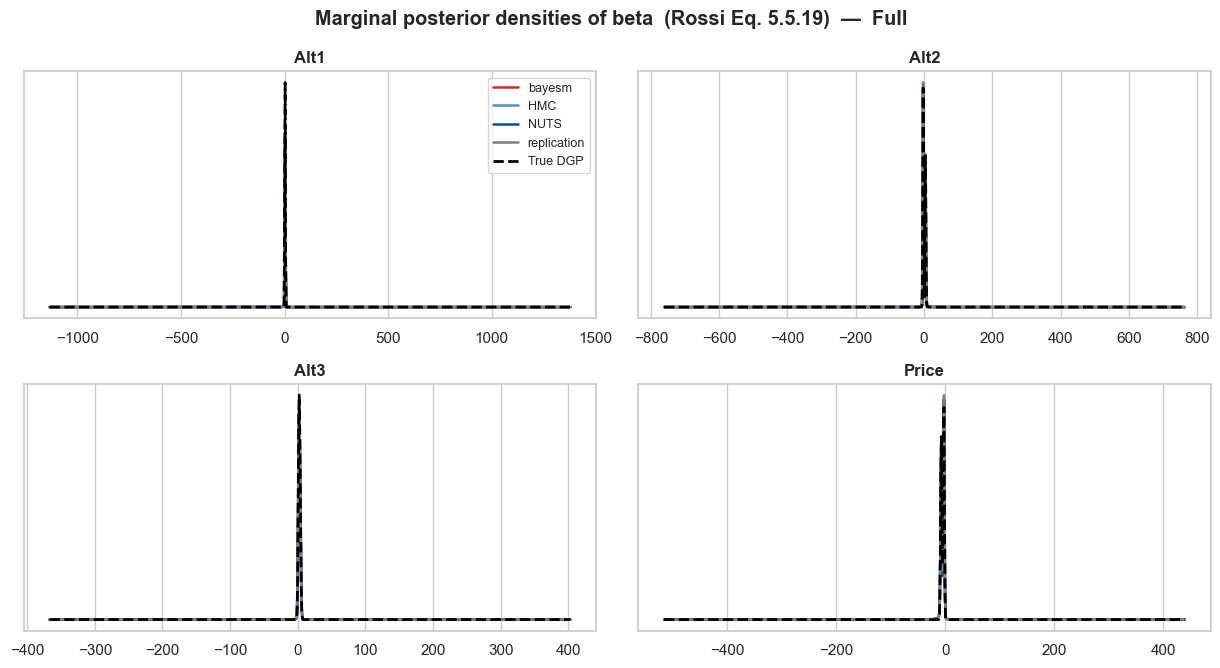

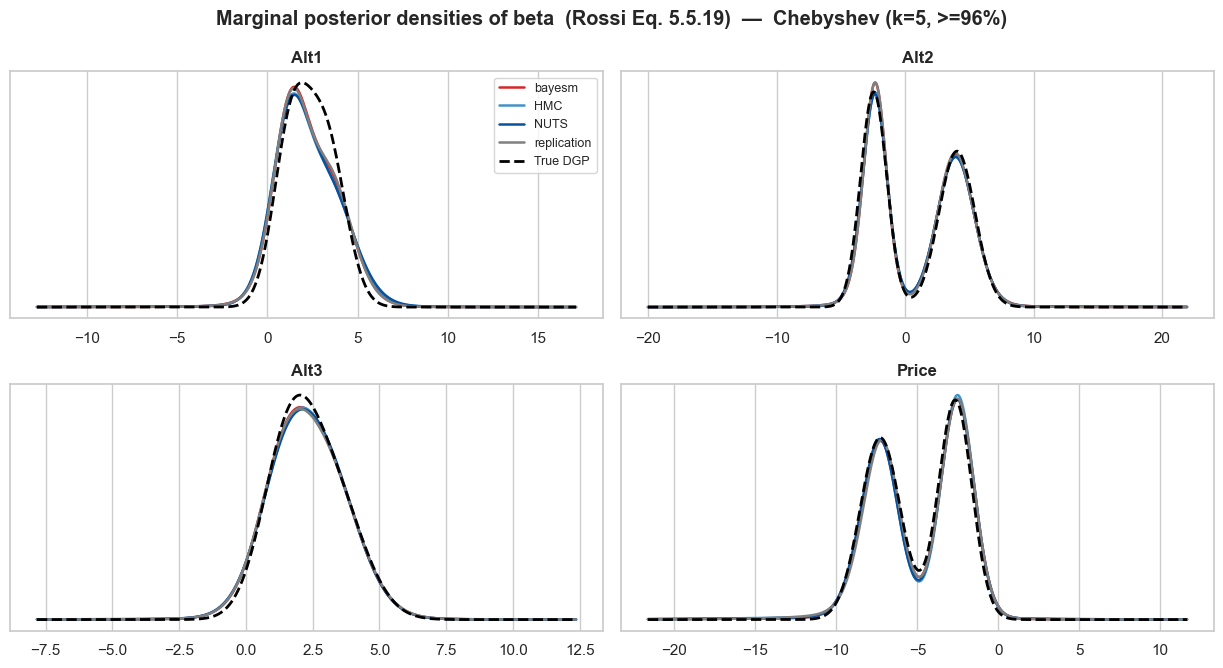

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) - Full vs Chebyshev-filtered ──────────
# True DGP = black (dashed reference), bayesm = red, Liesel samplers = distinct
# shades of blue (ColorBrewer Blues: dark -> light). One figure per grid pass.
# `marginal_density` is O(R*K*n_grid) per model - computed ONCE per (model, grid)
# pass here and cached in DENS/DENS_TRUE so Cells 5 and 7 reuse it instead of
# recomputing it internally.
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "iwls": "#9ecae1", "bayesm": "#d62728"}
TRUE_COLOR = "#000000"
ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))

DENS, DENS_TRUE = {}, {}
for label, grids in GRIDS.items():
    dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
    dens_true = mc.marginal_density(true_model, grids)
    DENS[label], DENS_TRUE[label] = dens, dens_true

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
    ax = axes.ravel()
    for j, pj in enumerate(param_names):
        for name, d in dens.items():
            ax[j].plot(grids[j], d[j], lw=1.8, label=name, color=colors.get(name, "#7f7f7f"))
        ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="True DGP")
        ax[j].set_title(pj, fontweight="bold")
        ax[j].set_yticks([])
    for j in range(P, len(ax)):
        ax[j].set_visible(False)
    ax[0].legend(fontsize=9)
    fig.suptitle(f"Marginal posterior densities of beta  (Rossi Eq. 5.5.19)  \u2014  {label}",
                 fontweight="bold")
    fig.tight_layout()
    plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP - Full vs Chebyshev-filtered ──────────
# Every sampler's marginal is compared ONLY to the True DGP marginal (never to
# another sampler). Metrics: Hellinger (primary), KL(model||true), Jensen-Shannon,
# total-variation, Wasserstein-1. All label-invariant - relabeling/ECR would not
# change them. The two passes differ only in the integration grid built in Cell 3;
# distances typically shrink under "Chebyshev" once the diffuse/outlier tails that
# dominate "Full" are clipped out. Reuses the densities cached in Cell 4 (DENS,
# DENS_TRUE) rather than recomputing marginal_density a second time.
for label, grids in GRIDS.items():
    print(f"--- {label} ---")
    display(mc.distance_table(models, true_model, grids, param_names,
                               dens=DENS[label], dens_true=DENS_TRUE[label]))

--- Full ---


C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMultinomialLogit\src\marginal_comparison.py:265: RuntimeWarning: overflow encountered in divide
  term = np.where((a > 0) & (b > 0), a * np.log(a / np.where(b > 0, b, 1.0)), 0.0)


Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.11891      inf  0.01309  0.13073       0.38503
            Alt2     0.07083      inf  0.00427  0.03785       0.13841
            Alt3     0.05727      inf  0.00277  0.02627       0.08595
            Price    0.09174      inf  0.00657  0.05012       0.25504
HMC         Alt1     0.13865      inf  0.01732  0.15010       0.54042
            Alt2     0.07998      inf  0.00512  0.03877       0.21700
            Alt3     0.07056      inf  0.00399  0.02802       0.13517
            Price    0.09935      inf  0.00770  0.05497       0.27142
NUTS        Alt1     0.13853      inf  0.01719  0.14718       0.54236
            Alt2     0.07883      inf  0.00492  0.03768       0.23605
            Alt3     0.07389      inf  0.00436  0.03016       0.14364
            Price    0.09274      inf  0.00677  0.04865       0.25289
replication Alt1     0.11786  0.20253  0.01285  0.13093       0.38698
            Alt2     0.06858      inf  0.00397  0.03629       0.14610
            Alt3     0.06061      inf  0.00307  0.02842       0.10421
            Price    0.09697      inf  0.00745  0.05278       0.28657

--- Chebyshev (k=5, >=96%) ---


Hellinger       KL      JSD      TVD  Wasserstein1
sampler     param                                                    
bayesm      Alt1     0.10848  0.11534  0.01082  0.09453       0.25617
            Alt2     0.06950  0.08199  0.00411  0.04286       0.13295
            Alt3     0.05375  0.03516  0.00250  0.02523       0.07473
            Price    0.08349  0.22325  0.00557  0.04755       0.20613
HMC         Alt1     0.12547  0.21238  0.01431  0.10886       0.30900
            Alt2     0.07241  0.16137  0.00430  0.04161       0.14906
            Alt3     0.05885  0.05012  0.00293  0.02622       0.07663
            Price    0.09540  0.29137  0.00717  0.05287       0.24264
NUTS        Alt1     0.12729  0.22477  0.01467  0.10787       0.30839
            Alt2     0.07060  0.16700  0.00405  0.03853       0.15392
            Alt3     0.06120  0.05706  0.00317  0.02881       0.07945
            Price    0.08780  0.22082  0.00615  0.04668       0.21544
replication Alt1     0.10558  0.13252  0.01021  0.09264       0.25253
            Alt2     0.06637  0.08683  0.00374  0.04177       0.13363
            Alt3     0.05523  0.03935  0.00263  0.02710       0.08021
            Price    0.08766  0.17200  0.00625  0.05017       0.20837

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
# Grid-independent - computed analytically from the draws, not by integrating over
# either grid - so this runs once for both passes above.
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,2.209,2.181,2.170,2.203,2.307
Alt2,0.875,0.927,0.960,0.892,0.791
Alt3,2.292,2.268,2.267,2.283,2.357
Price,-4.973,-4.935,-4.951,-4.990,-4.978


diag Var[theta]  (overall mixture variance):


,bayesm,HMC,NUTS,replication,True DGP
Alt1,3.093,7.837,8.924000,3.094,1.982
Alt2,12.361,15.337,17.589001,12.701,12.009
Alt3,2.361,3.847,4.076000,2.886,1.840
Price,9.704,9.397,9.463000,11.083,6.678


In [7]:
# ── Cell 7 : Invariant Convergence - Marginal Density Series - Full vs Chebyshev-filtered ──────────
# ESS / R-hat (arviz rank-normalised split-R-hat) of the label-invariant per-draw
# marginal density, over the high-density region of each parameter. The density mask
# (density_threshold) is relative to each grid's own peak, so both passes restrict to
# their own high-density region even though "Full" spans a much wider range. Reuses
# the densities cached in Cell 4 (DENS) rather than recomputing marginal_density a
# third time just to rebuild the mask.
if CHAINS == 1:
    print("NOTE: single chain -> R-hat is SPLIT-R-hat (the one chain is halved); a")
    print("      WITHIN-chain check only (Vehtari et al. 2021; Stan; BDA3 sec. 11.4).")
    print("      It cannot detect multimodality a lone chain never explored - the")
    print("      between-chain R-hat comes from the 2-chain runs.\n")
for label, grids in GRIDS.items():
    print(f"=== Grid: {label} ===")
    for m in models:
        print(f"--- {m['name']} ---")
        display(mc.density_series_diagnostics(m, grids, param_names, n_eval=40,
                                               marg=DENS[label][m["name"]]).round(3))

NOTE: single chain -> R-hat is SPLIT-R-hat (the one chain is halved); a
      WITHIN-chain check only (Vehtari et al. 2021; Stan; BDA3 sec. 11.4).
      It cannot detect multimodality a lone chain never explored - the
      between-chain R-hat comes from the 2-chain runs.

=== Grid: Full ===
--- bayesm ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,2,392.513,762.404,1.004,1.002
Alt2,2,260.694,292.275,1.012,1.010
Alt3,2,364.357,765.187,1.003,1.003
Price,1,2085.959,2085.959,1.001,1.001


--- HMC ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,4,47.287,63.715,1.044,1.035
Alt2,3,68.895,85.485,1.027,1.015
Alt3,4,87.482,114.332,1.026,1.019
Price,1,180.711,180.711,1.004,1.004


--- NUTS ---


...

,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,13,12.233,54.712,1.115,1.039
Alt2,14,5.930,92.000,1.248,1.046
Alt3,17,45.049,115.225,1.040,1.013
Price,16,6.088,173.887,1.253,1.039


--- NUTS ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,13,185.957,523.758,1.020,1.008
Alt2,14,47.771,756.311,1.043,1.007
Alt3,17,353.060,759.136,1.012,1.003
Price,16,38.805,1142.246,1.049,1.010


--- replication ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt1,13,118.812,248.566,1.021,1.011
Alt2,14,14.943,400.231,1.103,1.016
Alt3,17,172.312,434.971,1.017,1.006
Price,17,46.205,566.993,1.042,1.015


In [8]:
# ── Cell 8 : Invariant Convergence - Moment Series & Notes ──────────
# Grid-independent, like Cell 6 - runs once.
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.moment_series_diagnostics(m, param_names).round(4))

print("\nNotes:")
print(" - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is")
print("   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,")
print("   so relabeling/ECR is unnecessary and would give identical results.")
print(" - Two grids are compared throughout: 'Full' (unbounded envelope over every")
print("   component of every sampler + True DGP - nothing excluded, but can be very")
print("   wide when a sampler explores far off the high-density area or K_MODEL >")
print("   K_TRUE) and 'Chebyshev (k=5, >=96%)' (clipped to each model's own aggregate")
print("   mixture mean +/- 5 std - a distribution-free bound guaranteeing at least 96%")
print("   of that model's own marginal mass is retained, regardless of shape).")
print(" - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)")
print("   series (Vehtari et al. 2021). For 1-chain runs the single chain is split")
print("   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's")
print("   seed-based chains are not over-dispersed, so its R-hat is a weaker test")
print("   than NUTS/HMC.")

--- bayesm ---


ESS    Rhat
param moment                  
Alt1  Mean    290.2729  1.0166
      Var     505.9402  1.0063
Alt2  Mean    496.1786  1.0064
      Var     145.2468  1.0182
Alt3  Mean    642.7892  1.0033
      Var     898.5981  1.0014
Price Mean     30.2314  1.0473
      Var      12.1916  1.1231

--- HMC ---


ESS    Rhat
param moment                  
Alt1  Mean     95.9350  1.0200
      Var      52.1053  1.0394
Alt2  Mean     51.3963  1.0181
      Var      48.2056  1.0519
Alt3  Mean    101.8333  1.0092
      Var      96.8397  1.0080
Price Mean     18.4450  1.0780
      Var       7.7766  1.1915

--- NUTS ---


ESS    Rhat
param moment                  
Alt1  Mean    375.1328  1.0046
      Var     325.7585  1.0090
Alt2  Mean    360.1675  1.0129
      Var     197.3972  1.0095
Alt3  Mean    374.5280  1.0019
      Var     304.8499  1.0061
Price Mean     93.4955  1.0215
      Var      44.3305  1.0478

--- replication ---


ESS    Rhat
param moment                  
Alt1  Mean    478.2941  1.0016
      Var     193.9647  1.0118
Alt2  Mean    741.2153  1.0026
      Var      18.1295  1.0866
Alt3  Mean    107.1782  1.0117
      Var     113.9433  1.0218
Price Mean      8.2388  1.1679
      Var       4.6876  1.3466


Notes:
 - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is
   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,
   so relabeling/ECR is unnecessary and would give identical results.
 - Two grids are compared throughout: 'Full' (unbounded envelope over every
   component of every sampler + True DGP - nothing excluded, but can be very
   wide when a sampler explores far off the high-density area or K_MODEL >
   K_TRUE) and 'Chebyshev (k=5, >=96%)' (clipped to each model's own aggregate
   mixture mean +/- 5 std - a distribution-free bound guaranteeing at least 96%
   of that model's own marginal mass is retained, regardless of shape).
 - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)
   series (Vehtari et al. 2021). For 1-chain runs the single chain is split
   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's
   seed-based chains are not over-dispersed, so its R-hat is a weaker test
   th